In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
df = pd.read_csv("customer_churn_dataset-testing-master.csv")





In [3]:

print("\n First Three Rows are")
print(df.head(3))



 First Three Rows are
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  


In [4]:
df.shape

(64374, 12)

In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 5.9 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,32187.500000,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,41.970982,13.924911,18.0,30.00,42.0,54.00,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.00,33.0,47.00,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.00,15.0,23.00,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.00,6.0,8.00,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.00,19.0,25.00,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.00,534.0,768.00,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.00,15.0,23.00,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.00,0.0,1.00,1.0


In [8]:
missing_values = pd.DataFrame({
    
    'Missing Values': df.isnull().sum(),
    'Percentage':(df.isnull().sum()/len(df))*100
})
missing_values 

,Missing Values,Percentage
CustomerID,0,0.0
Age,0,0.0
Gender,0,0.0
Tenure,0,0.0
Usage Frequency,0,0.0
Support Calls,0,0.0
Payment Delay,0,0.0
Subscription Type,0,0.0
Contract Length,0,0.0
Total Spend,0,0.0


In [9]:
duplicate_summary = pd.DataFrame({
    "Metric": ["Duplicate Rows"],
    "Count": [df.duplicated().sum()]
})
duplicate_summary

,Metric,Count
0,Duplicate Rows,0


#### Performing  EDA

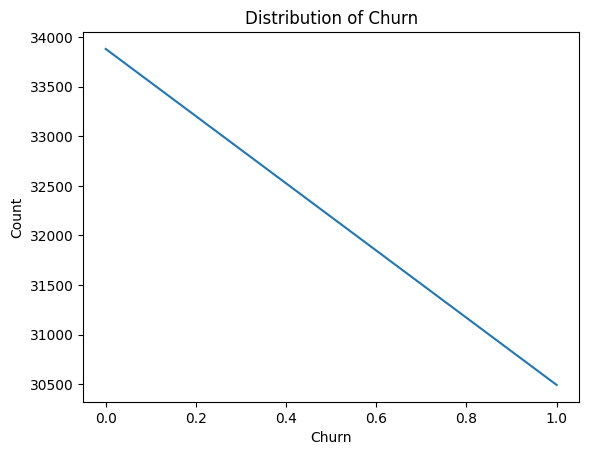

In [10]:
plt.plot(df['Churn'].value_counts())
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

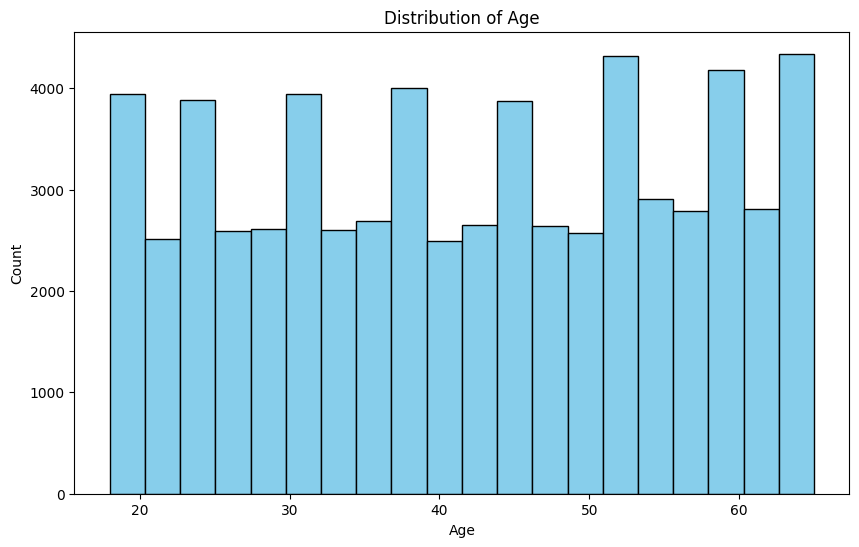

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distribution of Age')
plt.show()

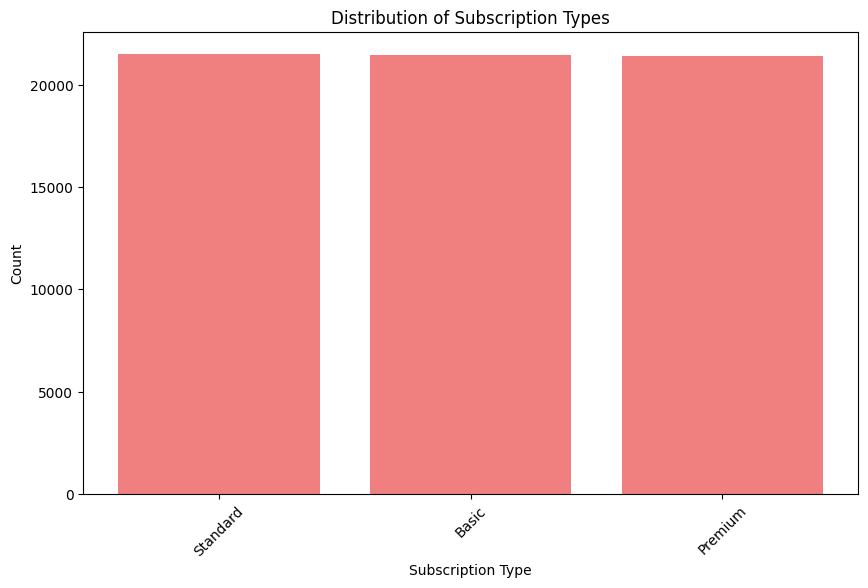

In [15]:
sub = df["Subscription Type"].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(sub.index, sub.values, color='lightcoral')
plt.xlabel('Subscription Type')
plt.ylabel('Count')
plt.title('Distribution of Subscription Types')
plt.xticks(rotation=45)
plt.show()


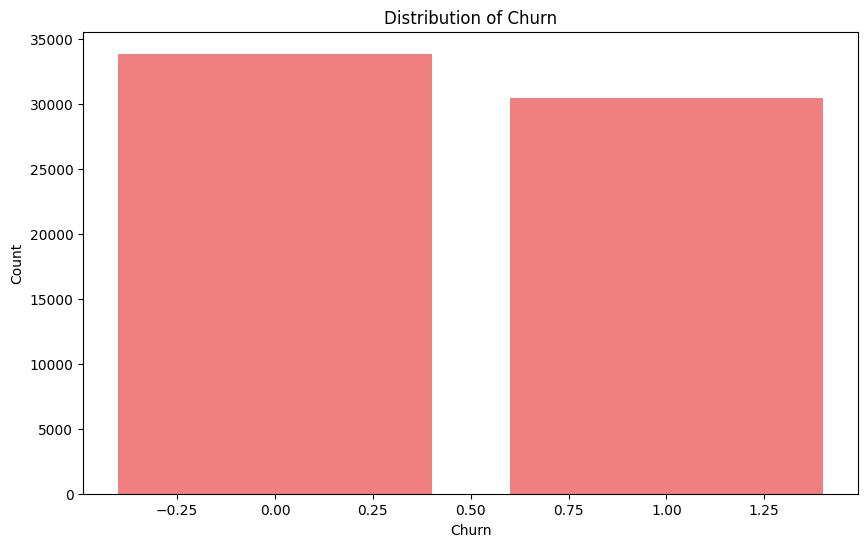

In [16]:
churn = df["Churn"].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(churn.index, churn.values, color='lightcoral')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

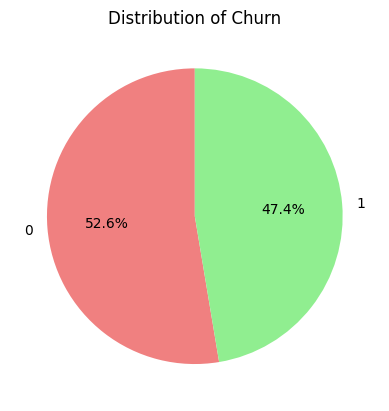

In [17]:
plt.pie(churn.values, labels=churn.index, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightgreen'])
plt.title('Distribution of Churn')
plt.show()

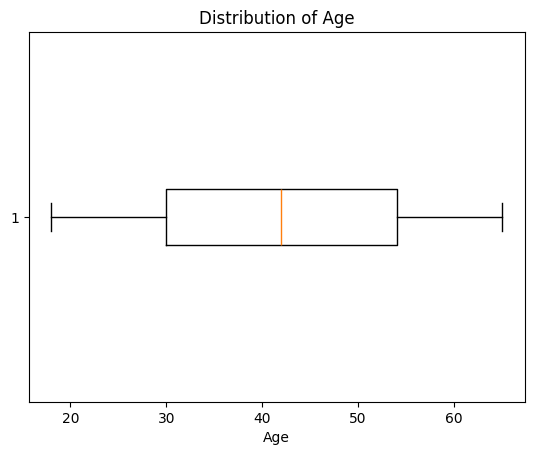

In [18]:
plt.boxplot(df['Age'], vert=False)
plt.xlabel('Age')
plt.title('Distribution of Age')
plt.show()

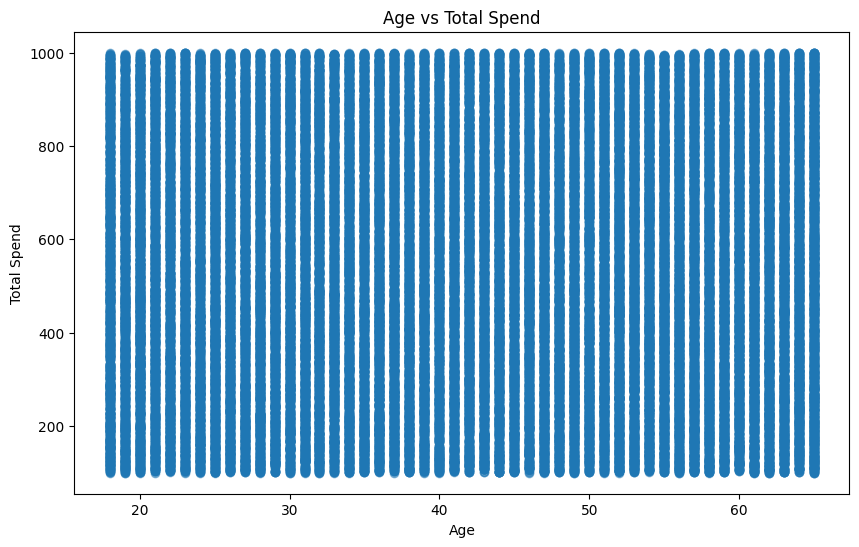

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Total Spend'], alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Total Spend')
plt.show()

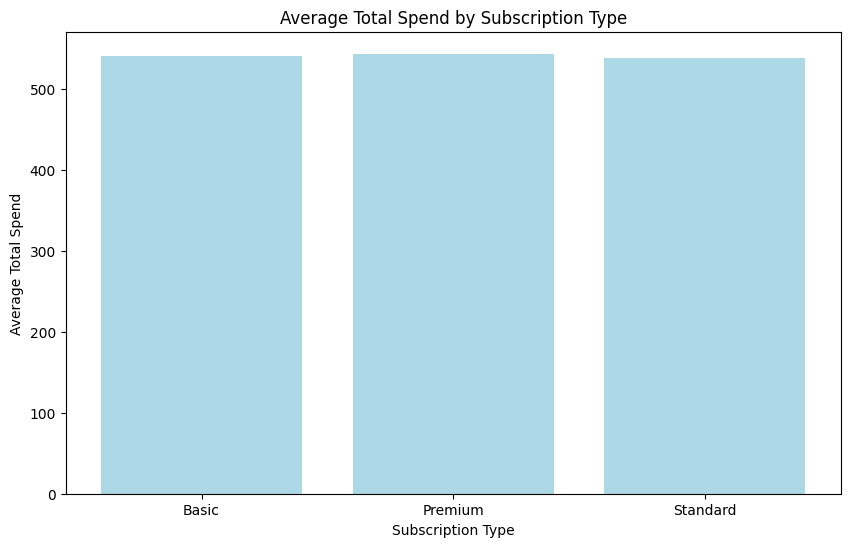

In [21]:
avg = df.groupby('Subscription Type')['Total Spend'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg.index, avg.values, color='lightblue')
plt.xlabel('Subscription Type')
plt.ylabel('Average Total Spend')
plt.title('Average Total Spend by Subscription Type')
plt.show()

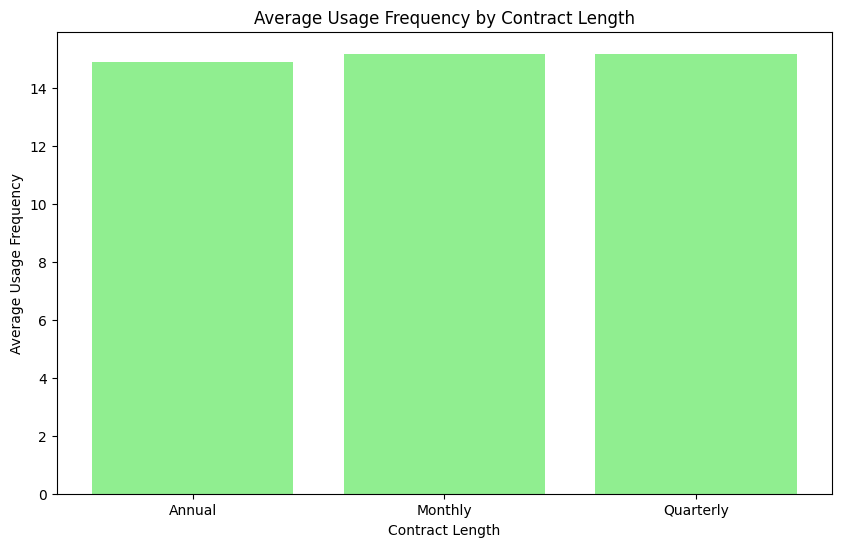

In [22]:
avg =df.groupby("Contract Length")["Usage Frequency"].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg.index, avg.values, color='lightgreen')
plt.xlabel('Contract Length')
plt.ylabel('Average Usage Frequency')
plt.title('Average Usage Frequency by Contract Length')
plt.show()

#
==================================
=========
# Machine Learning Model: Random Forest Classifier
#
=================================
========


In [10]:
X = df[['Age', 'Subscription Type', 'Contract Length', 'Usage Frequency', 'Total Spend']]
y = df['Churn']

categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(exclude="object").columns


C:\Users\themi\AppData\Local\Temp\ipykernel_3032\4099430523.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include="object").columns


In [11]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [12]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [16]:
param_grid = {

    "model__n_estimators": [100],

    "model__max_depth": [10],

    "model__min_samples_split": [2],

    "model__min_samples_leaf": [1]
}

In [17]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [10], 'model__min_samples_leaf': [1], 'model__min_samples_split': [2], 'model__n_estimators': [100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ve

In [18]:
print(grid.best_params_)
y_pred = grid.predict(X_test)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy: 0.5880388349514563
[[5516 1260]
 [4044 2055]]


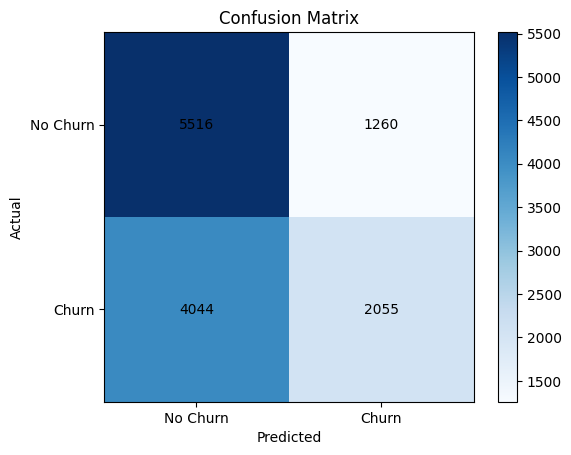

In [21]:
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0,1],["No Churn","Churn"])
plt.yticks([0,1],["No Churn","Churn"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix")

plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.81      0.68      6776
           1       0.62      0.34      0.44      6099

    accuracy                           0.59     12875
   macro avg       0.60      0.58      0.56     12875
weighted avg       0.60      0.59      0.56     12875



In [25]:


try:
    model = joblib.load("model.pkl")
    print("✅ Model Loaded Successfully")
except Exception as e:
    print("❌ Error Loading Model")
    print(e)

✅ Model Loaded Successfully


In [26]:
joblib.dump(grid.best_estimator_, "model.pkl")
print("Model saved successfully")

Model saved successfully


In [28]:
model = joblib.load("model.pkl")
print("Model loaded successfully")

Model loaded successfully


In [29]:
joblib.dump(grid.best_estimator_, "model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
